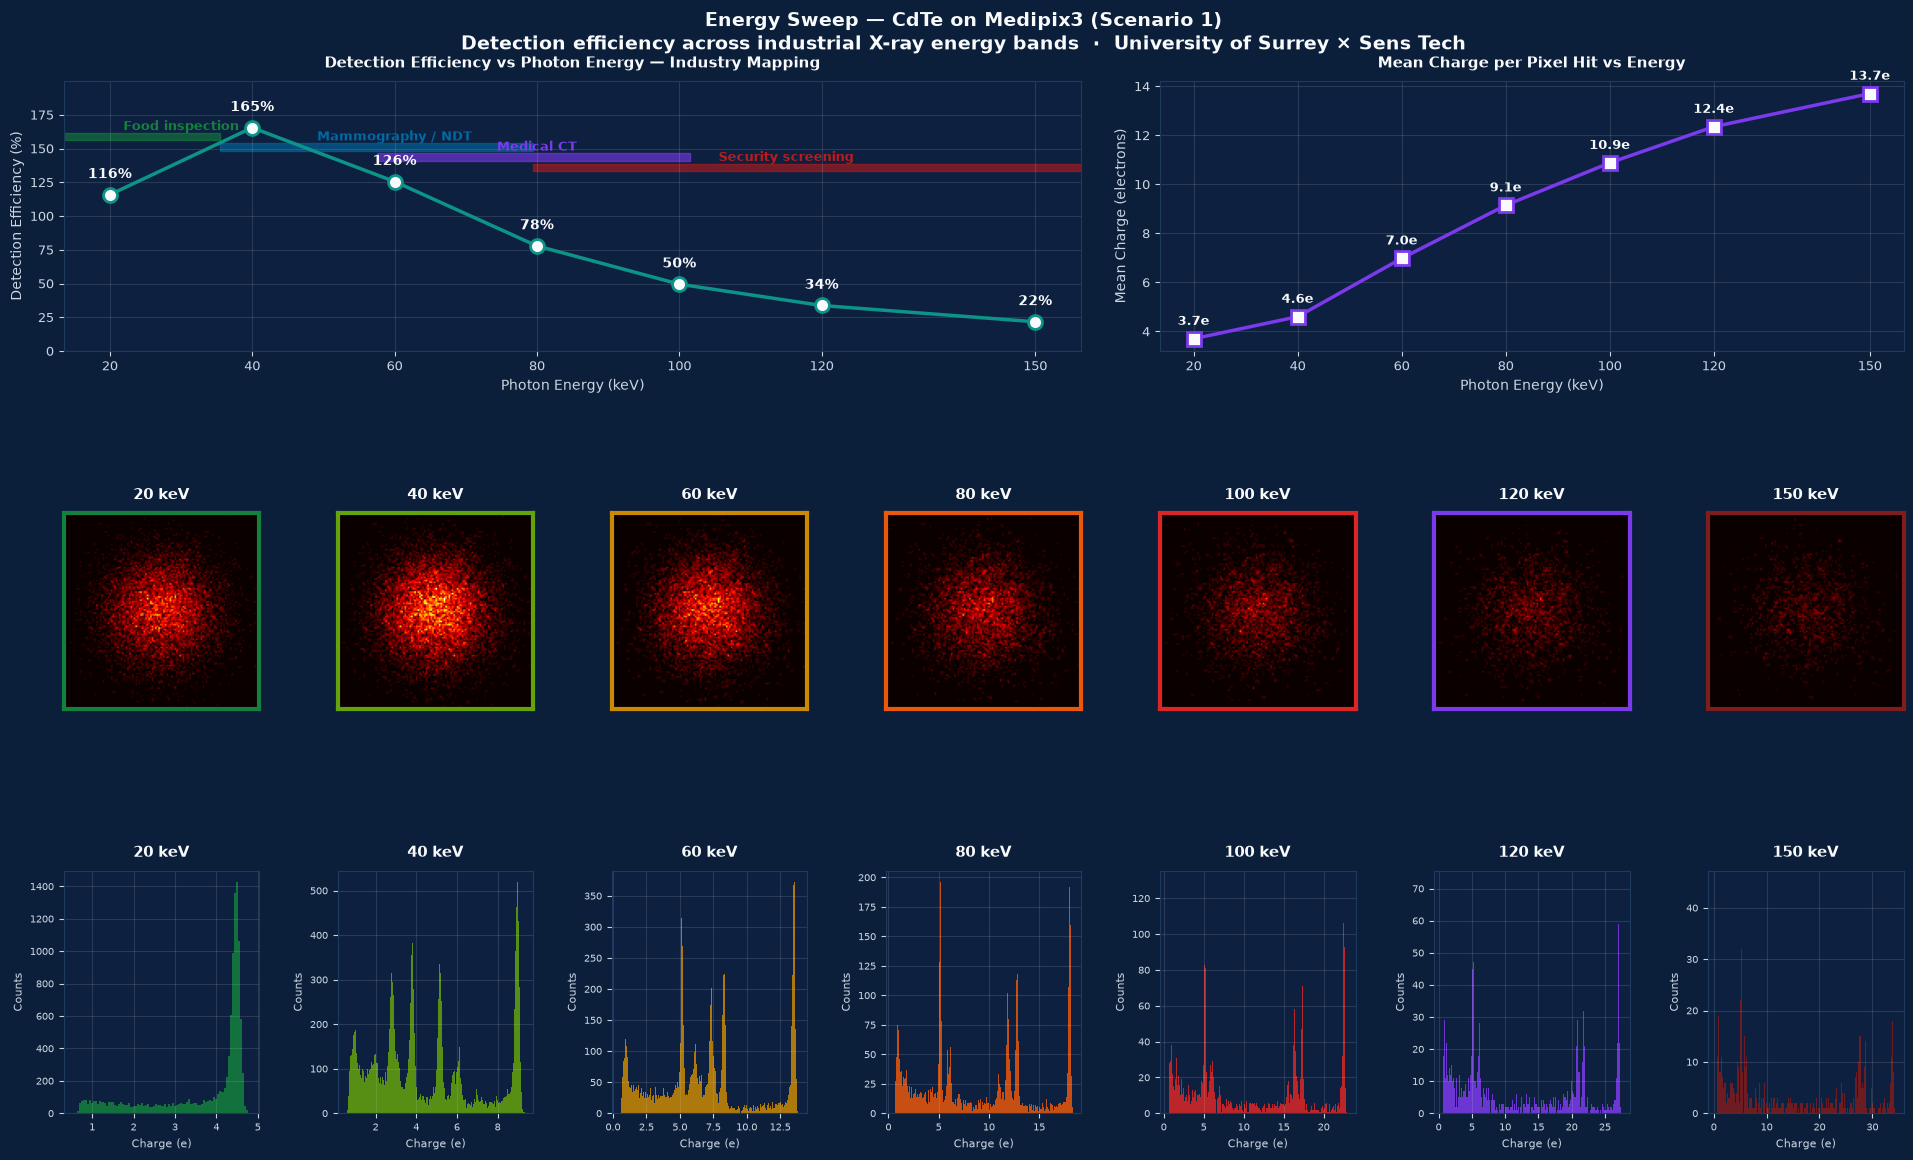

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/s1_energy_dashboard.png

── Summary ───────────────────────────────────
    20 keV → 11,580 hits | 115.8% eff | mean charge   3.7e
    40 keV → 16,547 hits | 165.5% eff | mean charge   4.6e
    60 keV → 12,554 hits | 125.5% eff | mean charge   7.0e
    80 keV →  7,786 hits |  77.9% eff | mean charge   9.1e
   100 keV →  4,952 hits |  49.5% eff | mean charge  10.9e
   120 keV →  3,373 hits |  33.7% eff | mean charge  12.4e
   150 keV →  2,166 hits |  21.7% eff | mean charge  13.7e


In [1]:
"""
Scenario 1 — Energy Sweep Dashboard
CdTe on Medipix3 across 20-150 keV
Maps detector performance to industry application bands.
"""

import os
os.environ["QT_QPA_PLATFORM"] = "xcb"

import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE = os.path.expanduser("~/itek/senstech-simulation/data")
DET = "medipix3_detector"

energies = [20, 40, 60, 80, 100, 120, 150]
n_events = 10000

# ── Extract data ──────────────────────────────────────────────────────────
results = []
hit_maps = []
charge_specs = []

for E in energies:
    path = os.path.join(BASE, f"s1_cdte_{E}keV.root")
    f = uproot.open(path)
    pixel_charge = f[f"DetectorHistogrammer/{DET}/charge/pixel_charge;1"].to_numpy()
    cluster_charge = f[f"DetectorHistogrammer/{DET}/charge/cluster_charge;1"].to_numpy()
    hit_map = f[f"DetectorHistogrammer/{DET}/hit_map;1"].to_numpy()
    cluster_size = f[f"DetectorHistogrammer/{DET}/cluster_size/cluster_size;1"].to_numpy()

    hits = int(pixel_charge[0].sum())
    mean_q = np.average(pixel_charge[1][:-1], weights=pixel_charge[0] + 1e-9)
    mean_cs = np.average(cluster_size[1][:-1], weights=cluster_size[0] + 1e-9)

    results.append({
        "energy": E, "hits": hits,
        "efficiency": (hits / n_events) * 100,
        "mean_charge": mean_q, "mean_cluster": mean_cs,
    })
    hit_maps.append(hit_map[0])
    charge_specs.append(pixel_charge)

# ── Style ─────────────────────────────────────────────────────────────────
NAVY, WHITE, LGRAY, GRAY = "#0B1F3A", "#F8FAFC", "#CBD5E1", "#64748B"
TEAL, BLUE, PURP, AMBER = "#0D9488", "#0369A1", "#7C3AED", "#D97706"

def style_ax(ax, title):
    ax.set_facecolor("#0D2040")
    ax.tick_params(colors=LGRAY, labelsize=9)
    ax.xaxis.label.set_color(LGRAY); ax.yaxis.label.set_color(LGRAY)
    ax.title.set_color(WHITE)
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)
    for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
    ax.grid(True, alpha=0.15, color=LGRAY)

# Industry zones (energy ranges)
zones = [
    (20, 40,  "#15803D", "Food inspection"),
    (40, 80,  "#0369A1", "Mammography / NDT"),
    (60, 100, "#7C3AED", "Medical CT"),
    (80, 150, "#B91C1C", "Security screening"),
]

# ── Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(NAVY)
gs = gridspec.GridSpec(3, 7, figure=fig, hspace=0.55, wspace=0.4,
                       left=0.05, right=0.97, top=0.92, bottom=0.06,
                       height_ratios=[1, 0.9, 0.9])

# Panel 1 — efficiency curve with industry zones
ax1 = fig.add_subplot(gs[0, :4])
style_ax(ax1, "Detection Efficiency vs Photon Energy — Industry Mapping")
effs = [r["efficiency"] for r in results]
ax1.plot(energies, effs, color=TEAL, linewidth=2.5,
         marker="o", markersize=10, markerfacecolor=WHITE,
         markeredgewidth=2, zorder=10)
for r in results:
    ax1.annotate(f"{r['efficiency']:.0f}%", xy=(r["energy"], r["efficiency"]),
                 xytext=(0, 12), textcoords="offset points", ha="center",
                 color=WHITE, fontsize=10, fontweight="bold")
# Industry zones as shaded bands
ymax = max(effs) * 1.15
for ymin, color, label in [(ymax*0.85, c, l) for (_,_,c,l) in zones]:
    pass
for i, (e0, e1, color, label) in enumerate(zones):
    y_band = ymax * (0.82 - i*0.04)
    ax1.axhspan(y_band, y_band + ymax*0.03, xmin=(e0-20)/(150-20),
                xmax=(e1-20)/(150-20), color=color, alpha=0.6)
    ax1.text((e0+e1)/2, y_band + ymax*0.04, label,
             ha="center", color=color, fontsize=9, fontweight="bold")
ax1.set_xlabel("Photon Energy (keV)")
ax1.set_ylabel("Detection Efficiency (%)")
ax1.set_xticks(energies)
ax1.set_ylim(0, ymax * 1.05)

# Panel 2 — mean charge per hit
ax2 = fig.add_subplot(gs[0, 4:])
style_ax(ax2, "Mean Charge per Pixel Hit vs Energy")
charges = [r["mean_charge"] for r in results]
ax2.plot(energies, charges, color=PURP, linewidth=2.5,
         marker="s", markersize=10, markerfacecolor=WHITE, markeredgewidth=2)
for r in results:
    ax2.annotate(f"{r['mean_charge']:.1f}e", xy=(r["energy"], r["mean_charge"]),
                 xytext=(0, 10), textcoords="offset points", ha="center",
                 color=WHITE, fontsize=9, fontweight="bold")
ax2.set_xlabel("Photon Energy (keV)")
ax2.set_ylabel("Mean Charge (electrons)")
ax2.set_xticks(energies)

# Row 2 — hit maps
colors_row = ["#15803D", "#65A30D", "#CA8A04", "#EA580C", "#DC2626", "#7C3AED", "#7F1D1D"]
for i, E in enumerate(energies):
    ax = fig.add_subplot(gs[1, i])
    style_ax(ax, f"{E} keV")
    hm = hit_maps[i]
    c = hm.shape[0] // 2; cr = 60
    im = ax.imshow(hm[c-cr:c+cr, c-cr:c+cr], cmap="hot", origin="lower",
                   aspect="equal", vmax=max(h.max() for h in hit_maps))
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor(colors_row[i]); s.set_linewidth(3)

# Row 3 — charge spectra
for i, E in enumerate(energies):
    ax = fig.add_subplot(gs[2, i])
    style_ax(ax, f"{E} keV")
    vals = charge_specs[i]
    m = vals[0] > 0
    ax.bar(vals[1][:-1][m], vals[0][m], width=np.diff(vals[1])[m],
           color=colors_row[i], alpha=0.85)
    ax.set_xlabel("Charge (e)", fontsize=8)
    ax.set_ylabel("Counts", fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle("Energy Sweep — CdTe on Medipix3 (Scenario 1)\n"
             "Detection efficiency across industrial X-ray energy bands  ·  University of Surrey × Sens Tech",
             fontsize=14, fontweight="bold", color=WHITE, y=0.98)

out = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks/s1_energy_dashboard.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

print("\n── Summary ───────────────────────────────────")
for r in results:
    print(f"  {r['energy']:>4} keV → {r['hits']:>6,} hits | {r['efficiency']:>5.1f}% eff | "
          f"mean charge {r['mean_charge']:>5.1f}e")